In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Create sample sales data for practice

months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

categories = {
    "Electronics": [12000, 15000, 14000, 18000, 20000, 22000],
    "Furniture":   [8000,  9000,  7500, 11000, 12000, 13000],
    "Clothing":    [5000,  6500,  7000,  8000,  7500, 10000]
}

rows = []

for category, sales_values in categories.items():
    for month, sales in zip(months, sales_values):
        rows.append({
            "Order Date": month,
            "Category": category,
            "Sales": sales
        })

df = pd.DataFrame(rows)

df.to_csv("sales_dataset.csv", index=False)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Order Date,Category,Sales
0,2026-01-01,Electronics,12000
1,2026-02-01,Electronics,15000
2,2026-03-01,Electronics,14000
3,2026-04-01,Electronics,18000
4,2026-05-01,Electronics,20000


In [ ]:
print("First five records:")
display(df.head())

print("Dataset dimensions:")
print(df.shape)

print("Column information:")
df.info()

print("Missing values:")
print(df.isnull().sum())

print("Summary statistics:")
display(df.describe())

First five records:


,Order Date,Category,Sales
0,2026-01-01,Electronics,12000
1,2026-02-01,Electronics,15000
2,2026-03-01,Electronics,14000
3,2026-04-01,Electronics,18000
4,2026-05-01,Electronics,20000


Dataset dimensions:
(18, 3)
Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  18 non-null     datetime64[ns]
 1   Category    18 non-null     object        
 2   Sales       18 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 564.0+ bytes
Missing values:
Order Date    0
Category      0
Sales         0
dtype: int64
Summary statistics:


,Order Date,Sales
count,18,18.000000
mean,2026-03-17 04:00:00,11416.666667
min,2026-01-01 00:00:00,5000.000000
25%,2026-02-01 00:00:00,7625.000000
50%,2026-03-16 12:00:00,10500.000000
75%,2026-05-01 00:00:00,13750.000000
max,2026-06-01 00:00:00,22000.000000
std,NaN,4842.368162


In [ ]:
# Convert the order date to datetime format
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

# Convert sales values to numeric format
df["Sales"] = pd.to_numeric(
    df["Sales"],
    errors="coerce"
)

# Remove rows missing essential values
df = df.dropna(
    subset=["Order Date", "Category", "Sales"]
)

# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())

print("Cleaned dataset:")
display(df.head())

Duplicate rows: 0
Cleaned dataset:


,Order Date,Category,Sales
0,2026-01-01,Electronics,12000
1,2026-02-01,Electronics,15000
2,2026-03-01,Electronics,14000
3,2026-04-01,Electronics,18000
4,2026-05-01,Electronics,20000


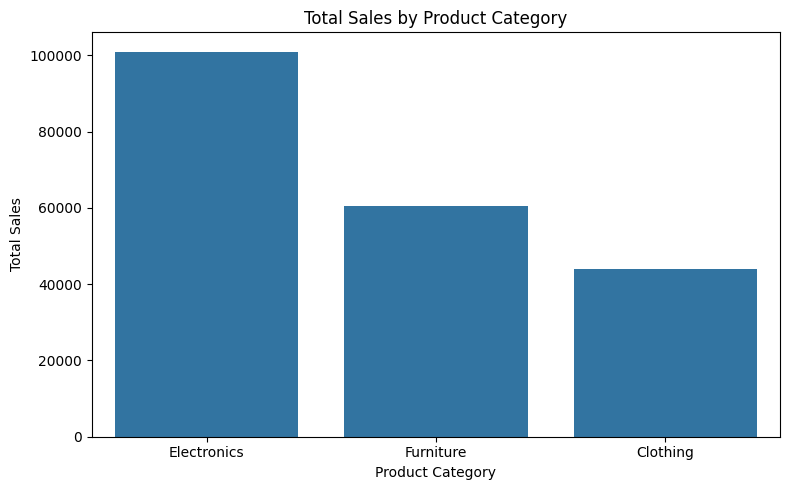

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

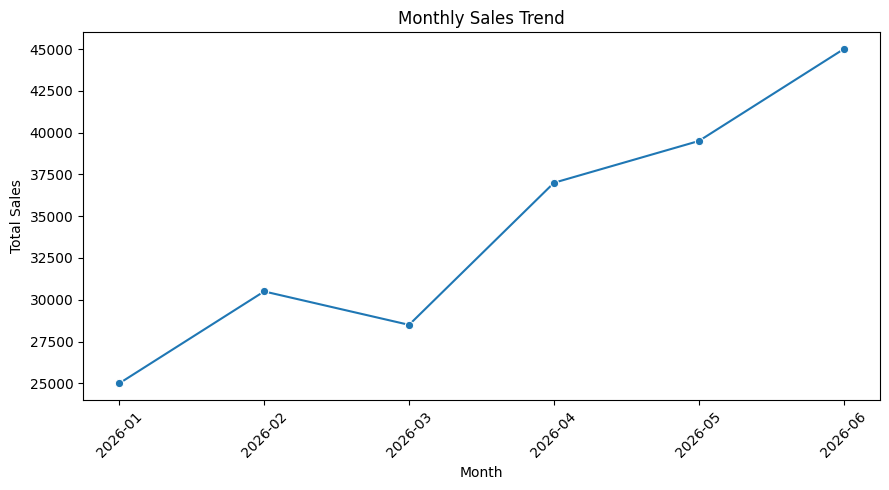

In [ ]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month"] = (
    monthly_sales["Month"].astype(str)
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

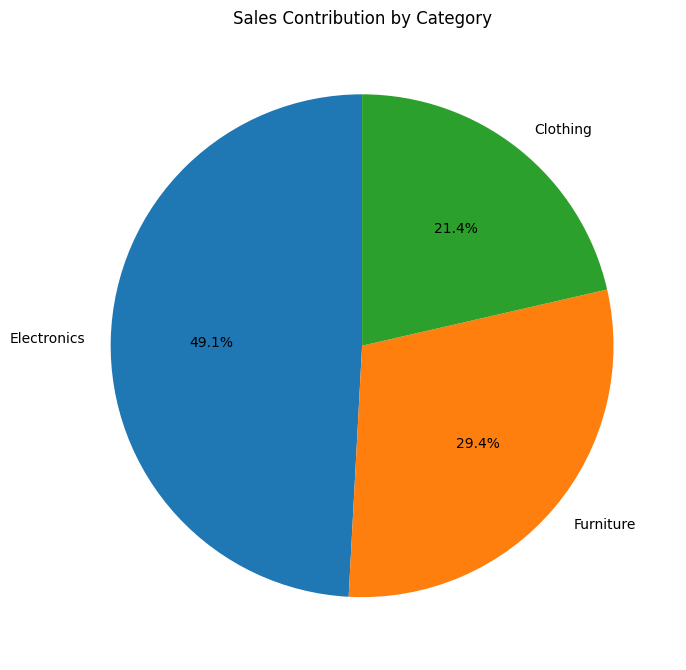

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Contribution by Category")
plt.tight_layout()
plt.savefig(
    "sales_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("TOTAL SALES BY CATEGORY")
print(category_sales)

print("\nMONTHLY SALES")
print(monthly_sales)

print("\nTOTAL SALES:", df["Sales"].sum())

TOTAL SALES BY CATEGORY
Category
Electronics    101000
Furniture       60500
Clothing        44000
Name: Sales, dtype: int64

MONTHLY SALES
     Month  Sales
0  2026-01  25000
1  2026-02  30500
2  2026-03  28500
3  2026-04  37000
4  2026-05  39500
5  2026-06  45000

TOTAL SALES: 205500


# Sales Data Visualization

## Project Objective
To analyze sales data and present meaningful insights through visualizations.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

## Visualizations
1. Total Sales by Product Category
2. Monthly Sales Trend
3. Sales Contribution by Category

## Dataset
This initial version uses simulated sales data created for learning and demonstration.

## Conclusion
The charts help compare category-wise sales, understand monthly changes, and examine each category's contribution to total sales.
